<a href="https://colab.research.google.com/github/ugun0811/wed_2026_bigdatacomputing/blob/main/%EC%A4%91%EA%B0%84%EA%B3%A0%EC%82%AC_%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  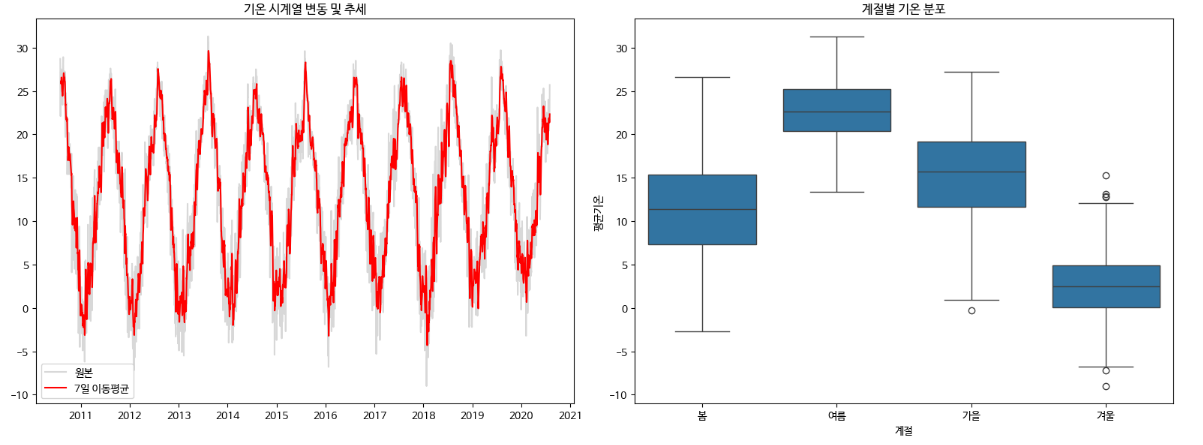

  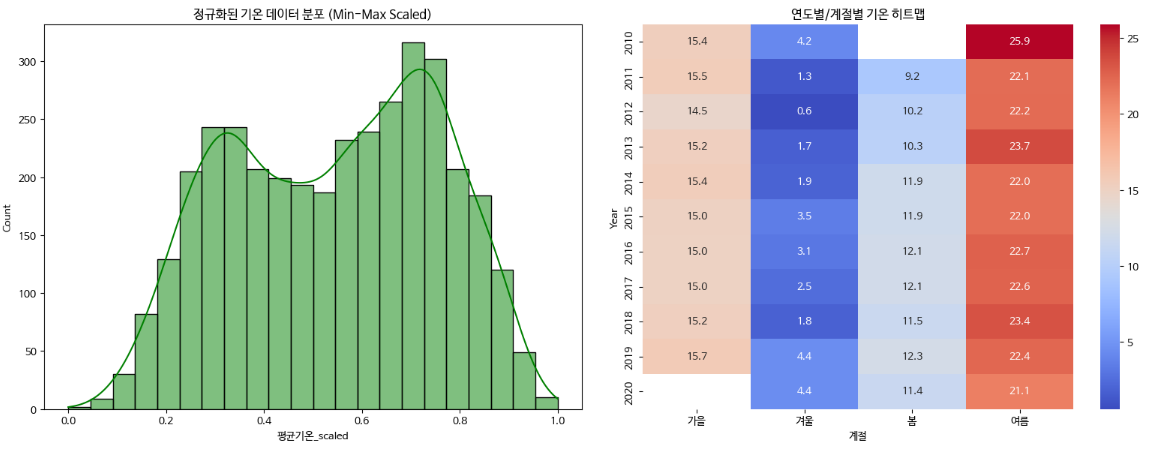



✅ 환경 설정 및 한글 폰트 로드 완료


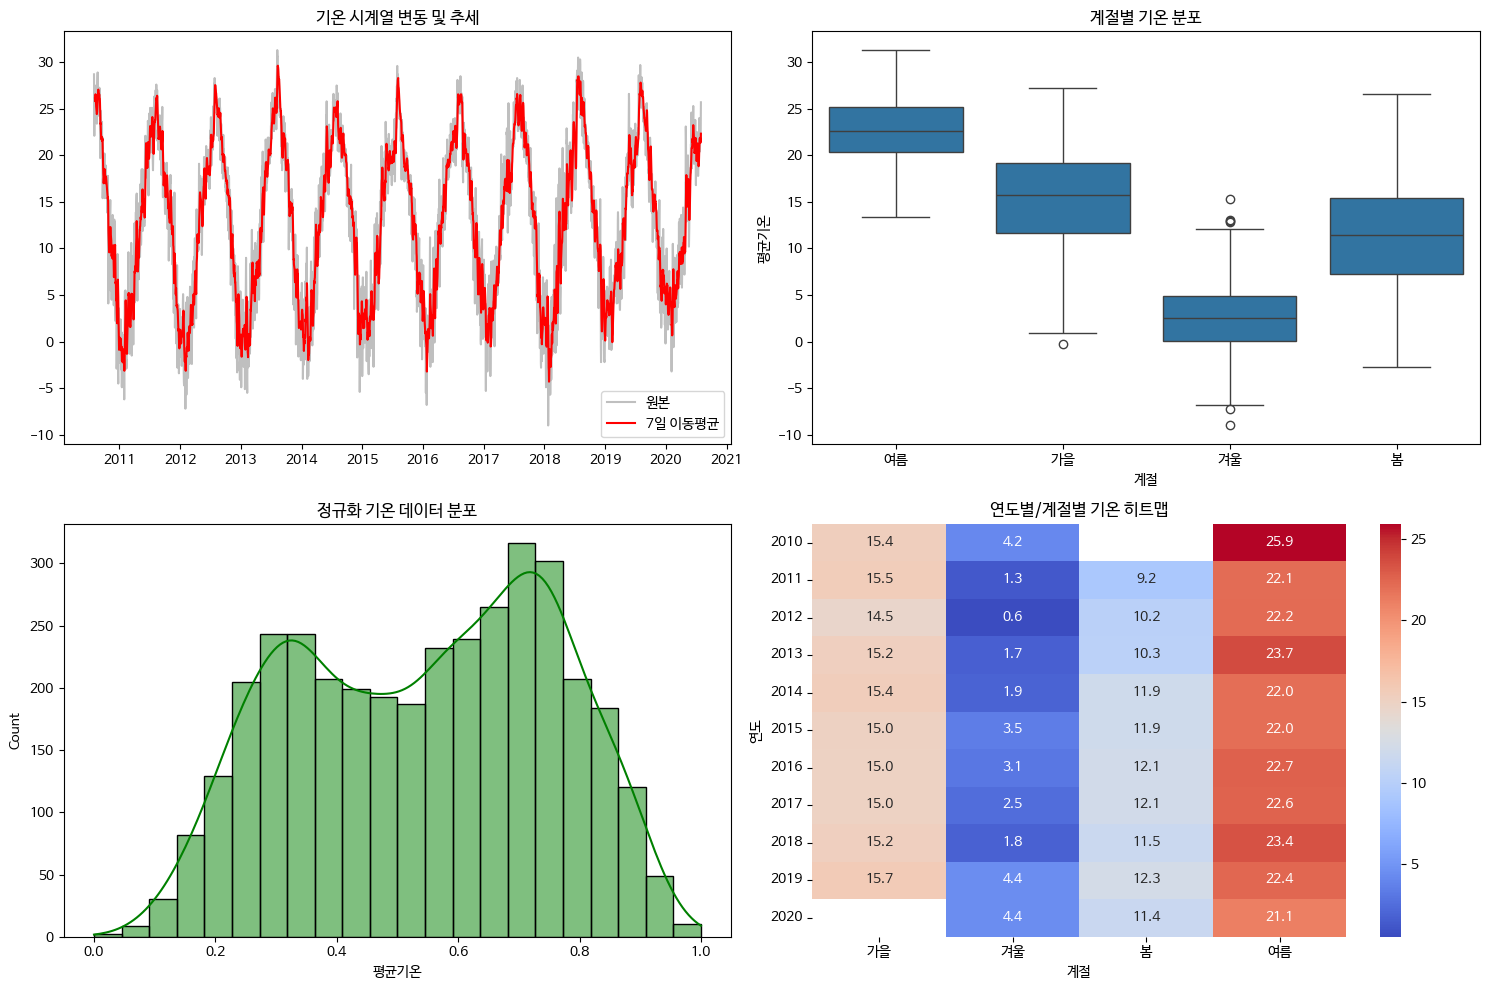

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import matplotlib.font_manager as fm

# 0. 환경 설정 (한글 폰트)
def setup_environment():
    warnings.filterwarnings('ignore')

    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    if not os.path.exists(font_path):
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')

    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rc('font', family='NanumBarunGothic')
    else:
        plt.rc('font', family='Malgun Gothic' if os.name == 'nt' else 'AppleGothic')

    plt.rcParams['axes.unicode_minus'] = False
    print("✅ 환경 설정 및 한글 폰트 로드 완료")

# 1. 데이터 로드
def load_data(url):
    try:
        return pd.read_csv(url, encoding='cp949')
    except:
        return pd.read_csv(url, encoding='euc-kr')

# 2. 전처리
def preprocess_data(df):
    df['일시'] = pd.to_datetime(df['일시'])
    df = df.sort_values('일시')
    df.set_index('일시', inplace=True)
    return df

# 3. Min-Max 정규화
def min_max_scaling(series):
    return (series - series.min()) / (series.max() - series.min())

# 4. 이동 평균
def add_moving_average(df):
    df['7일이동평균'] = df['평균기온'].rolling(window=7).mean()
    return df

# 5. 계절 추가
def add_season(df):
    def get_season(month):
        if month in [3,4,5]:
            return '봄'
        elif month in [6,7,8]:
            return '여름'
        elif month in [9,10,11]:
            return '가을'
        else:
            return '겨울'

    df['계절'] = df.index.month.map(get_season)
    return df

# 6. 계절 통계
def seasonal_stats(df):
    return df.groupby('계절')['평균기온'].describe()

# 7. 피벗 테이블
def create_pivot(df):
    df['연도'] = df.index.year
    pivot = pd.pivot_table(
        df,
        values='평균기온',
        index='연도',
        columns='계절',
        aggfunc='mean'
    )
    return pivot

# 8. 그래프
def plot_graphs(df, pivot):
    plt.figure(figsize=(15,10))

    # (1) 시계열
    plt.subplot(2,2,1)
    plt.plot(df.index, df['평균기온'], color='gray', alpha=0.5, label='원본')
    plt.plot(df.index, df['7일이동평균'], color='red', label='7일 이동평균')
    plt.title("기온 시계열 변동 및 추세")
    plt.legend()

    # (2) 박스플롯
    plt.subplot(2,2,2)
    sns.boxplot(x='계절', y='평균기온', data=df)
    plt.title("계절별 기온 분포")

    # (3) 히스토그램
    plt.subplot(2,2,3)
    scaled = min_max_scaling(df['평균기온'].dropna())
    sns.histplot(scaled, kde=True, color='green')
    plt.title("정규화 기온 데이터 분포")

    # (4) 히트맵
    plt.subplot(2,2,4)
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap="coolwarm")
    plt.title("연도별/계절별 기온 히트맵")

    plt.tight_layout()
    plt.show()

# 9. 엑셀 저장
def save_to_excel(df, seasonal, pivot):
    with pd.ExcelWriter("weather_analysis_report.xlsx") as writer:
        df.to_excel(writer, sheet_name='전처리데이터')
        seasonal.to_excel(writer, sheet_name='계절통계')
        pivot.to_excel(writer, sheet_name='피벗테이블')

# 10. 메인
def main():
    setup_environment()

    url = "https://github.com/dongupak/DataML/raw/main/csv/weather.csv"

    df = load_data(url)
    df = preprocess_data(df)
    df = add_moving_average(df)
    df = add_season(df)

    seasonal = seasonal_stats(df)
    pivot = create_pivot(df)

    plot_graphs(df, pivot)
    save_to_excel(df, seasonal, pivot)

# 실행
if __name__ == "__main__":
    main()